# Set-Up
Package and data importing

In [1]:
# essential package imports
import pandas as pd
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_and_prepare_lexical_df
from visualization import *

In [2]:
# read in data file as pandas dataframe
# raw_text is excluded via usecols to cut down read time
COLS_TO_LOAD = [
    'utterance_id',
    'speaker_id',
    'timestamp',
    'num_utterances_by_speaker',
    'num_utterances_by_speaker_month',
    'post_depth',
    'score',
    'num_direct_replies',
    'mtld_score',
    'mattr_score',
    'yules_k',
    'zipf_score',
    'aoa_score',
    'nawl_ratio',
    'source_variation',
    'subreddit',
]

METRICS = ['mtld_score', 'mattr_score', 'yules_k', 'zipf_score', 'aoa_score', 'nawl_ratio']

df = pd.read_csv(
    '/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/lexical_master.csv',
    usecols=COLS_TO_LOAD,
)

df = clean_and_prepare_lexical_df(df)

# User Frequency Analysis
Examine how user post frequency impacts lexical quality

## Posting Frequency Distribution Analysis
Examine the skew of speaker post-count distribution to motivate bin selection strategy.

In [3]:
from userfreq_analysis import summarize_freq_distribution, plot_freq_distribution

summarize_freq_distribution(df)

=== Speaker Post-Count Distribution ===
  N speakers      :    3,901,572
  Mean            :         9.96
  Median          :         2.00
  Std dev         :       120.28
  Skewness        :       114.13  (>1 = right-skewed)
  Excess kurtosis :     23270.26
  Min / Max       :      1 / 46,231

=== Percentiles ===
  P    1  :         1 posts
  P    5  :         1 posts
  P   10  :         1 posts
  P   25  :         1 posts
  P   50  :         2 posts
  P   75  :         4 posts
  P   90  :        13 posts
  P   95  :        26 posts
  P   99  :       122 posts
  P 99.9  :       812 posts

=== Low-Count Speaker Breakdown ===
  <=  1 post(s)  : 45.5% of speakers
  <=  2 post(s)  : 61.3% of speakers
  <=  3 post(s)  : 69.8% of speakers
  <=  5 post(s)  : 79.1% of speakers
  <= 10 post(s)  : 88.2% of speakers


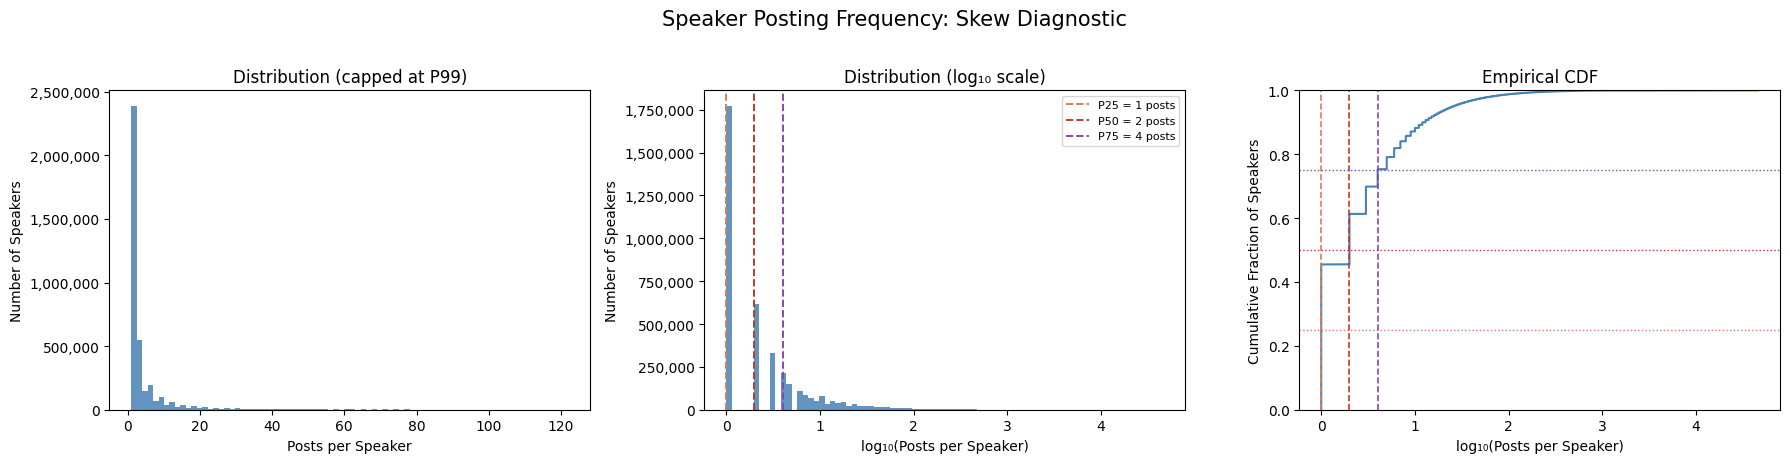

In [4]:
plot_freq_distribution(df)

## Data Prep

In [5]:
from userfreq_analysis import assign_freq_quartiles, prepare_panel

# For Analysis 2 (all speakers, no temporal filter)
df_q = assign_freq_quartiles(df)

# For Analysis 1 (speakers with >= min_obs monthly rows only)
panel = prepare_panel(df, min_obs=3)

Retained 1,401,807 / 3,901,572 speakers (35.9%) with >= 3 monthly observations.


## Initial Visualization

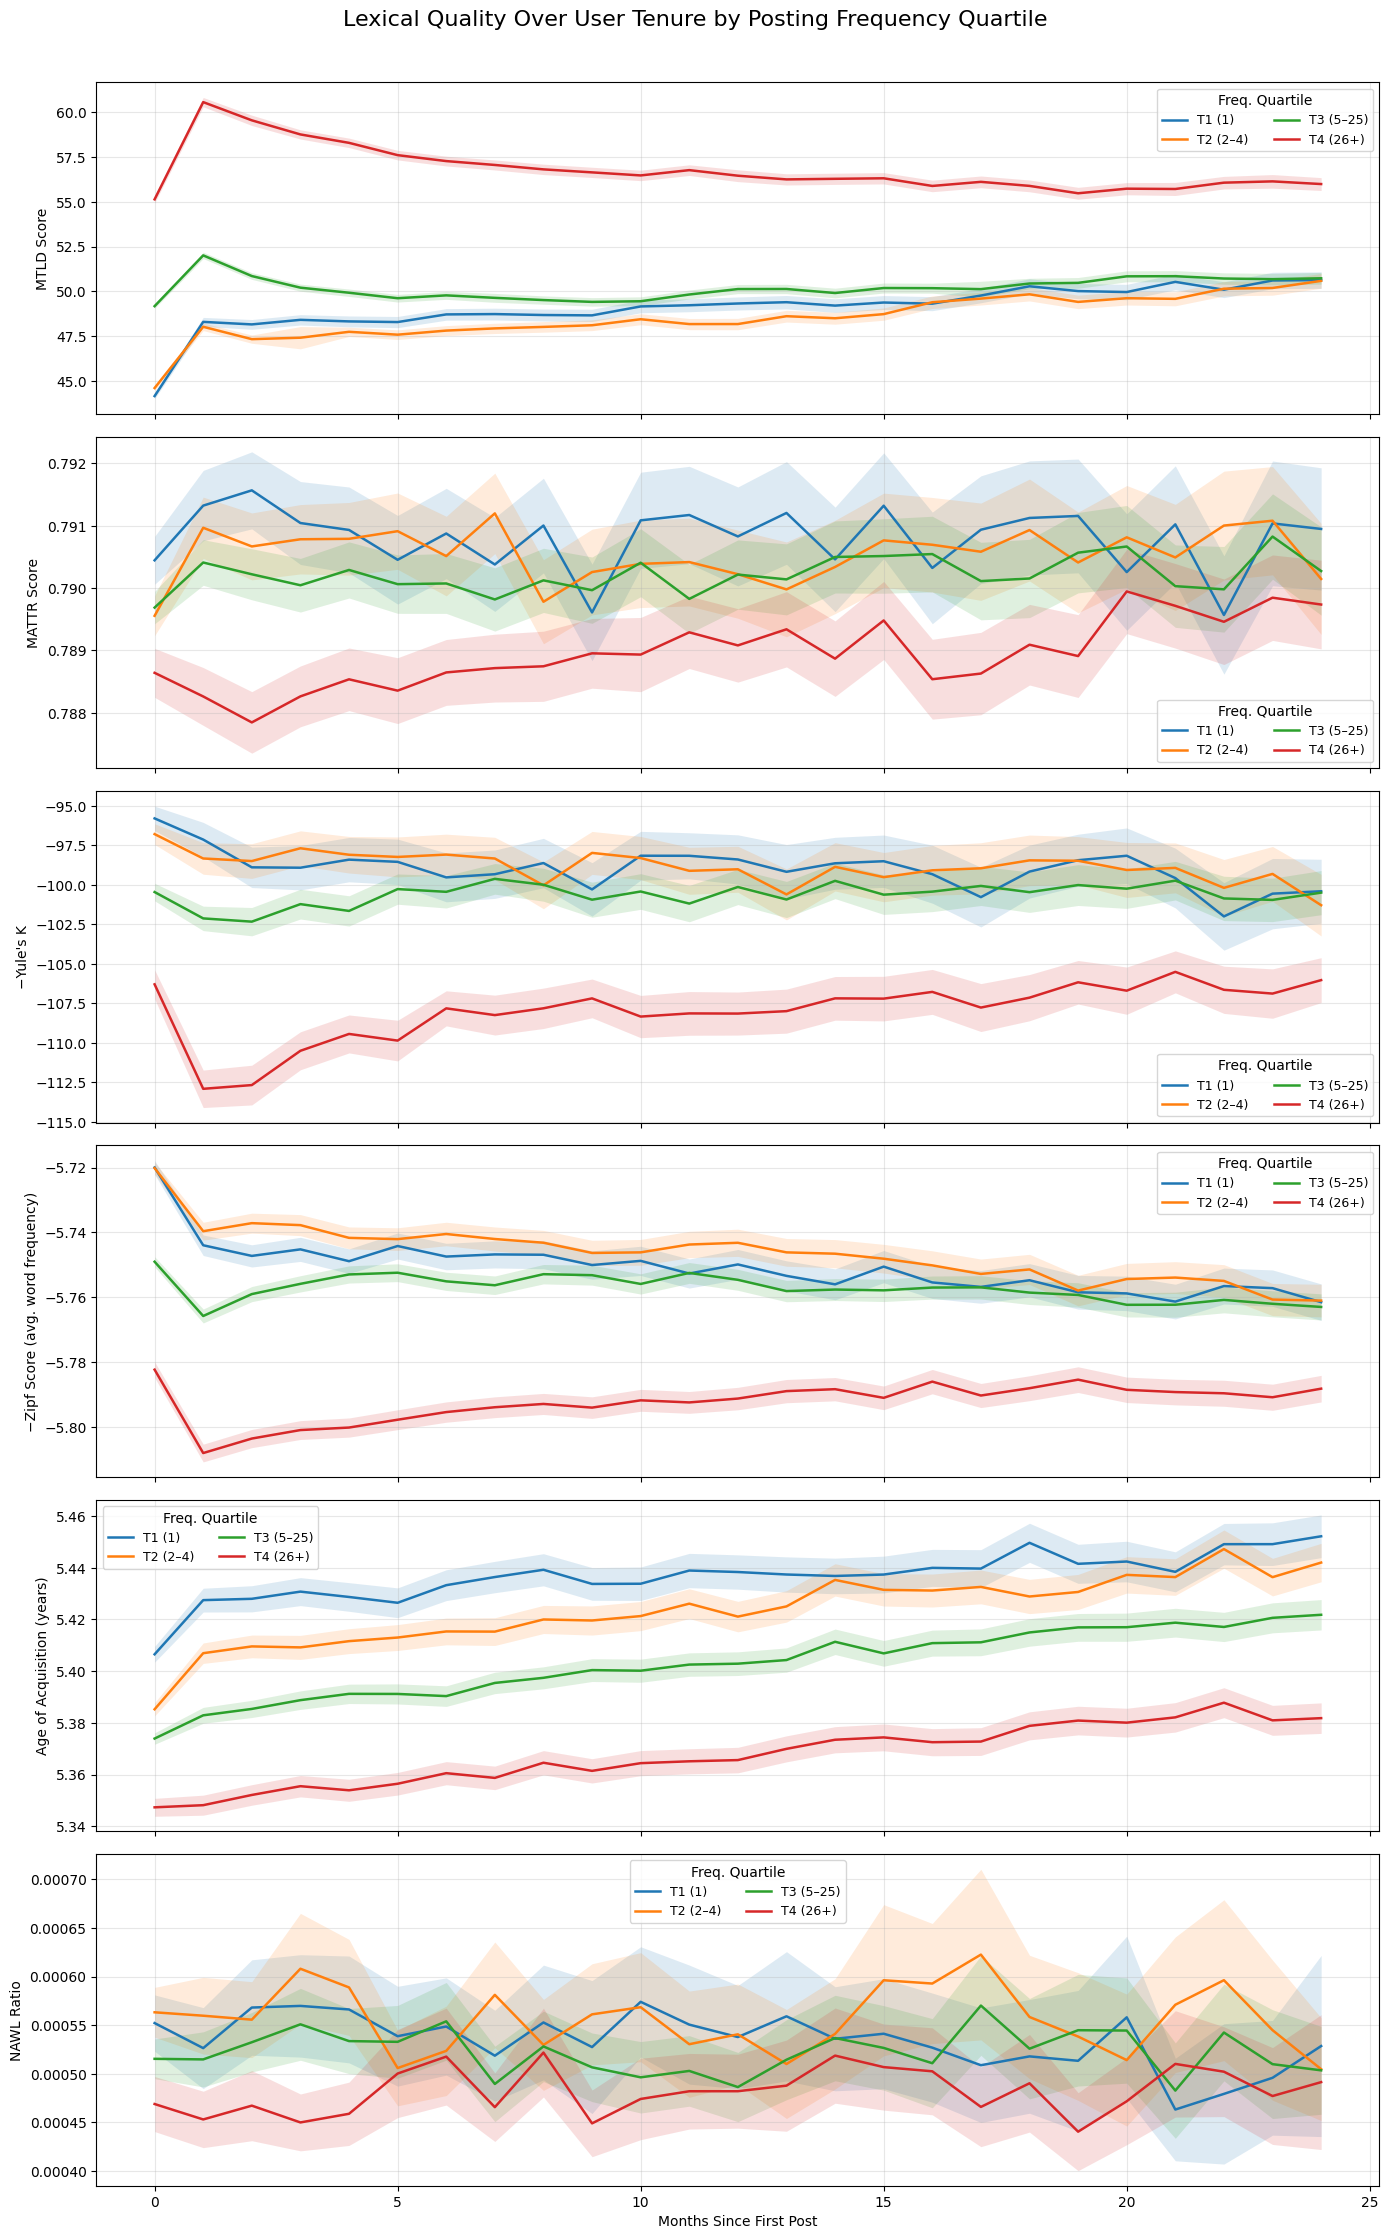

In [6]:
from userfreq_analysis import plot_quality_over_relative_time

plot_quality_over_relative_time(panel, max_relative_month=24)

## Analysis 2

In [7]:
from userfreq_analysis import plot_quality_by_freq_quartile, run_freq_quartile_tests
results = run_freq_quartile_tests(df_q)

In [8]:
from userfreq_analysis import compute_effect_sizes, plot_effect_size_heatmap

In [9]:
# Tidy table — display directly in the notebook
es = compute_effect_sizes(df_q)
es  # shows metric, group_1, group_2, r, magnitude, p_adjusted, significant

,metric,group_1,group_2,n_1,n_2,U_stat,r,magnitude,p_value,p_adjusted,significant
0,mtld_score,T1 (1),T2 (2–4),1774845,1162613,8.297260e+11,-0.1958,small,0.000000,0.000000,True
1,mtld_score,T1 (1),T3 (5–25),1774845,766277,4.754200e+11,-0.3009,medium,0.000000,0.000000,True
2,mtld_score,T1 (1),T4 (26+),1774845,197837,1.104723e+11,-0.3708,medium,0.000000,0.000000,True
3,mtld_score,T2 (2–4),T3 (5–25),1162613,766277,3.965829e+11,-0.1097,small,0.000000,0.000000,True
4,mtld_score,T2 (2–4),T4 (26+),1162613,197837,9.217154e+10,-0.1985,small,0.000000,0.000000,True
5,mtld_score,T3 (5–25),T4 (26+),766277,197837,6.817445e+10,-0.1006,small,0.000000,0.000000,True
6,mattr_score,T1 (1),T2 (2–4),518450,588777,1.525398e+11,-0.0006,negligible,0.608649,0.626039,False
7,mattr_score,T1 (1),T3 (5–25),518450,577540,1.495658e+11,-0.0010,negligible,0.374180,0.396190,False
8,mattr_score,T1 (1),T4 (26+),518450,183526,4.779766e+10,0.0047,negligible,0.002782,0.003130,True
9,mattr_score,T2 (2–4),T3 (5–25),588777,577540,1.699383e+11,-0.0005,negligible,0.648673,0.648673,False


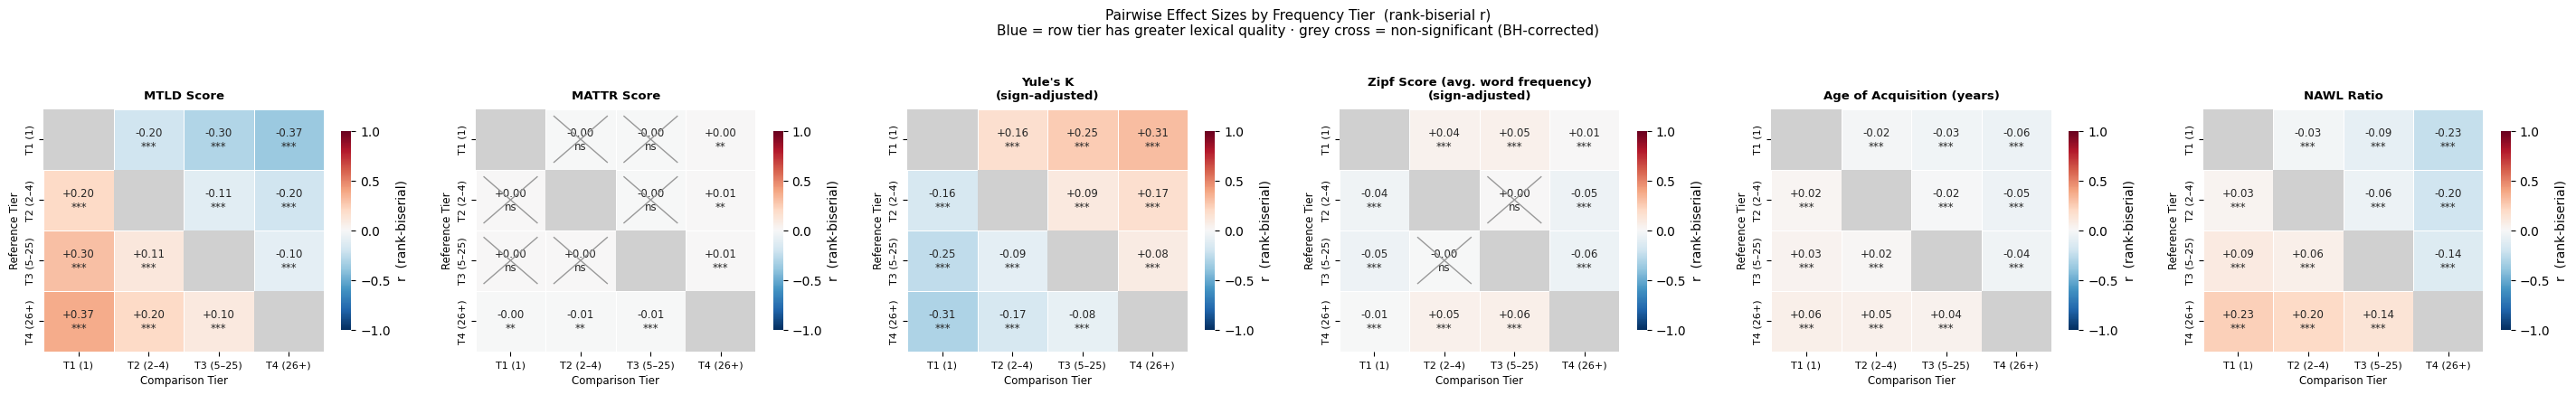

In [10]:
# Heatmap — one panel per metric
plot_effect_size_heatmap(df_q)

## Logistic Regression